# Baseline VLP model

This notebook is a simple end-to-end starter baseline for Task 1. It trains only on `data/train_clean_3x3_1cm.csv` and evaluates on the provided `data/validation_clean_3x3_1cm.csv`.

The notebook demonstrates:

1. loading the fixed cleaned 3x3 training and validation CSVs;
2. scaling RSS values and coordinate targets;
3. training a small MLP;
4. reporting positioning error in centimeters;
5. exporting the trained model to a `.tflite` flatbuffer with LiteRT Torch;
6. checking the TFLite model on the host;
7. exporting the same flatbuffer and scaling constants into the Pico firmware template.


In [2]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import csv
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from vlp_hackathon.baseline_model import BaselineMLP, OurMLP
from vlp_hackathon.export import tflite_to_c_array
from vlp_hackathon.metrics import euclidean_errors_cm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0


In [8]:
from vlp_hackathon.baseline_model import build_mlp

HIDDEN_SIZES = [256, 256, 64, 32]

## Load the fixed Task 1 train and validation CSVs

Task 1 data are already reduced to Configuration 2. Each CSV contains `x`, `y`, and these nine RSS channels:

```text
[0, 2, 4,
 12, 14, 16,
 24, 26, 28]
```

Coordinates are stored in millimeters and converted to centimeters. The raw 6x6 development dataset is not used for training this baseline.


In [9]:
TRAIN_CSV = ROOT / "data" / "train_clean_3x3_1cm.csv"
TEST_CSV_RAW = ROOT / "data" / "train_raw_3x3_1cm.csv"

VALIDATION_CSV = ROOT / "data" / "validation_clean_3x3_1cm.csv"
CONF1_COLUMNS = ["led_0", "led_1", "led_2", "led_3", "led_4", "led_5",
                 "led_6", "led_7", "led_8", "led_9", "led_10", "led_11",
                 "led_12", "led_13", "led_14", "led_15", "led_16", "led_17",
                 "led_18", "led_19", "led_20", "led_21", "led_22", "led_23",
                 "led_24", "led_25", "led_26", "led_27", "led_28", "led_29",
                 "led_30", "led_31", "led_32", "led_33", "led_34", "led_35"]
CONF2_COLUMNS = ["led_0", "led_2", "led_4", "led_12", "led_14", "led_16", "led_24", "led_26", "led_28"]

def load_task1_csv(path):
    rows = []
    with path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            rows.append([float(row["x"]), float(row["y"]), *[float(row[c]) for c in CONF2_COLUMNS]])
    arr = np.asarray(rows, dtype=np.float32)
    return arr[:, 2:], arr[:, :2] / 10.0

X_train_raw, y_train_cm = load_task1_csv(TRAIN_CSV)
X_test_raw, y_test_cm = load_task1_csv(TEST_CSV_RAW)
X_val_raw, y_val_cm = load_task1_csv(VALIDATION_CSV)

print("Training rows:", len(X_train_raw))
print("Validation rows:", len(X_test_raw))
print("Test shape:", X_test_raw.shape)
print("Test shape labels:", y_test_cm.shape)
print("Target x range (cm):", y_train_cm[:, 0].min(), "to", y_train_cm[:, 0].max())
print("Target y range (cm):", y_train_cm[:, 1].min(), "to", y_train_cm[:, 1].max())


Training rows: 42166
Validation rows: 126460
Test shape: (126460, 9)
Test shape labels: (126460, 2)
Target x range (cm): 0.0 to 281.0
Target y range (cm): 0.0 to 275.0


In [10]:
print("Using split files:")
print("  train:", TRAIN_CSV.name, len(X_train_raw), "rows")
print("  validation:", VALIDATION_CSV.name, len(X_val_raw), "rows")

Using split files:
  train: train_clean_3x3_1cm.csv 42166 rows
  validation: validation_clean_3x3_1cm.csv 4685 rows


## Simple preprocessing

The baseline scales RSS inputs by the maximum absolute RSS seen in the clean training view. Coordinate targets are normalized per axis to `[0, 1]`. The same constants are exported into the Pico firmware headers.

RSS scale: 0.8493868112564087
Target min cm: [0. 0.]
Target range cm: [281. 275.]


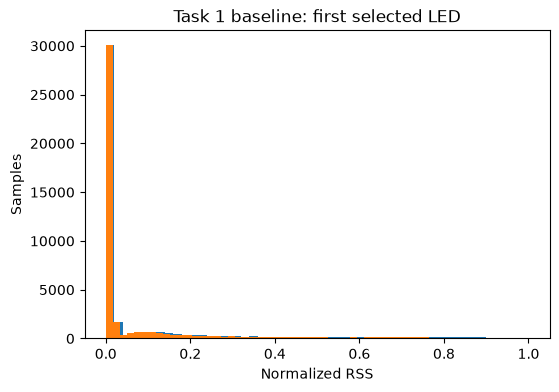

In [11]:
rss_scale = max(float(np.max(np.abs(X_train_raw))), 1e-8)
X_train = X_train_raw / rss_scale
X_val = X_val_raw / rss_scale

target_min_cm = y_train_cm.min(axis=0)
target_range_cm = np.maximum(y_train_cm.max(axis=0) - target_min_cm, 1e-8)
y_train = (y_train_cm - target_min_cm) / target_range_cm
y_val = (y_val_cm - target_min_cm) / target_range_cm

print("RSS scale:", rss_scale)
print("Target min cm:", target_min_cm)
print("Target range cm:", target_range_cm)

plt.figure(figsize=(6, 4))
plt.hist(X_train[:, 0], bins=50)
plt.hist(X_train_raw[:,0], bins=50)
plt.xlabel("Normalized RSS")
plt.ylabel("Samples")
plt.title("Task 1 baseline: first selected LED")
plt.show()

## Naive baseline MLP

The network is deliberately small and conventional: `9 -> 32 -> 32 -> 2`, with ReLU hidden activations and a sigmoid output. It is a starter baseline and should be improved for your submission.

In [12]:
# You may tune these
lr = 1e-3
epochs = 150
batch_size = 512

In [13]:
class GridNet(nn.Module):
    """Task 1 sketch: log-features + ReLU6 trunk + input skip connection.

    Design decisions:
    - log1p on the RSS inputs: RSS ~ 1/d^n, so log makes the signal->distance
      mapping near-linear and much easier for a small net. Exports as a LOG op
      (supported by TFLite Micro, but verify after int8 quantization).
    - ReLU6 instead of ReLU: bounded activation quantizes better to int8 and
      is TFLM-native.
    - Skip connection (input concatenated before the head): the head sees both
      the raw fingerprint and the learned features -- cheap, often helps small
      regressors.
    - Sigmoid head kept from the baseline: targets are normalized to [0, 1].
    """

    def __init__(self, input_features: int = 9, hidden: int = 32,
                 use_log: bool = True) -> None:
        super().__init__()
        self.use_log = use_log
        self.trunk = nn.Sequential(
            nn.Linear(input_features, hidden),
            nn.ReLU6(),
            nn.Linear(hidden, hidden),
            nn.ReLU6(),
        )
        # head input = hidden features + skipped raw input
        self.head = nn.Sequential(
            nn.Linear(hidden + input_features, 2),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_log:
            # clamp: raw RSS should be >= 0, but guard against noise
            x = torch.log1p(x.clamp(min=0.0))
        h = self.trunk(x)
        return self.head(torch.cat([h, x], dim=1))


class ConvGridNet(nn.Module):
    """Alternative sketch: treat the 9 channels as a 1x3x3 image.

    padding=1 keeps the 3x3 spatial size, so each LED position gets a
    neighborhood-aware feature. Mostly interesting as a warm-up for
    Task 3 (6x6), where the spatial prior actually pays off.
    """

    def __init__(self, channels: int = 8) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, padding=1),
            nn.ReLU6(),
        )
        self.head = nn.Sequential(
            nn.Linear(channels * 9, 32),
            nn.ReLU6(),
            nn.Linear(32, 2),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        img = x.view(-1, 1, 3, 3)          # (N, 9) -> (N, 1, 3, 3)
        h = self.conv(img).flatten(1)      # -> (N, channels*9)
        return self.head(h)


# model = GridNet(X_train.shape[1])
# model = ConvGridNet()
model = build_mlp(X_train.shape[1], HIDDEN_SIZES)


In [14]:
# model = build_mlp(X_train.shape[1], HIDDEN_SIZES)  # model now comes from the cell above
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)
print(model)

Sequential(
  (0): Linear(in_features=9, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=2, bias=True)
  (9): Sigmoid()
)


epoch=01 train_mse=0.032513 val_mse=0.004352
epoch=02 train_mse=0.003131 val_mse=0.001922
epoch=03 train_mse=0.001378 val_mse=0.000848
epoch=04 train_mse=0.000620 val_mse=0.000449
epoch=05 train_mse=0.000376 val_mse=0.000296
epoch=06 train_mse=0.000280 val_mse=0.000240
epoch=07 train_mse=0.000217 val_mse=0.000183
epoch=08 train_mse=0.000179 val_mse=0.000155
epoch=09 train_mse=0.000146 val_mse=0.000129
epoch=10 train_mse=0.000132 val_mse=0.000107
epoch=11 train_mse=0.000111 val_mse=0.000094
epoch=12 train_mse=0.000108 val_mse=0.000090
epoch=13 train_mse=0.000091 val_mse=0.000079
epoch=14 train_mse=0.000095 val_mse=0.000069
epoch=15 train_mse=0.000082 val_mse=0.000063
epoch=16 train_mse=0.000068 val_mse=0.000079
epoch=17 train_mse=0.000079 val_mse=0.000064
epoch=18 train_mse=0.000062 val_mse=0.000065
epoch=19 train_mse=0.000066 val_mse=0.000073
epoch=20 train_mse=0.000059 val_mse=0.000045
epoch=21 train_mse=0.000054 val_mse=0.000060
epoch=22 train_mse=0.000055 val_mse=0.000067
epoch=23 t

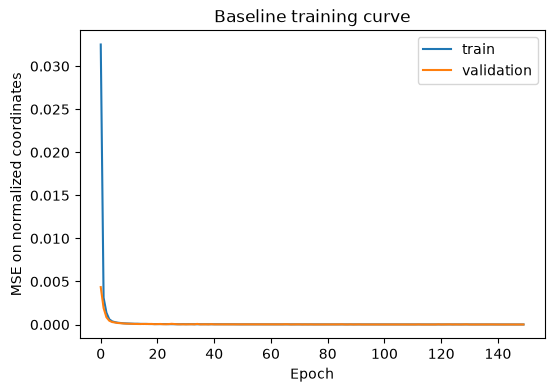

In [15]:
history = []
train_rng = np.random.default_rng(SEED)
for epoch in range(epochs):
    model.train()
    permutation = train_rng.permutation(len(X_train))
    running = 0.0
    for start in range(0, len(permutation), batch_size):
        idx = permutation[start:start + batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += float(loss.item()) * len(idx)

    model.eval()
    with torch.no_grad():
        val_loss = float(loss_fn(model(X_val_t), y_val_t).item())
    history.append((running / len(X_train), val_loss))
    print(f"epoch={epoch + 1:02d} train_mse={history[-1][0]:.6f} val_mse={val_loss:.6f}")

history = np.asarray(history, dtype=np.float32)
plt.figure(figsize=(6, 4))
plt.plot(history[:, 0], label="train")
plt.plot(history[:, 1], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE on normalized coordinates")
plt.legend()
plt.title("Baseline training curve")
plt.show()

Float validation mean error:   0.983 cm
Float validation median error: 0.844 cm
Float validation p95 error:    2.228 cm


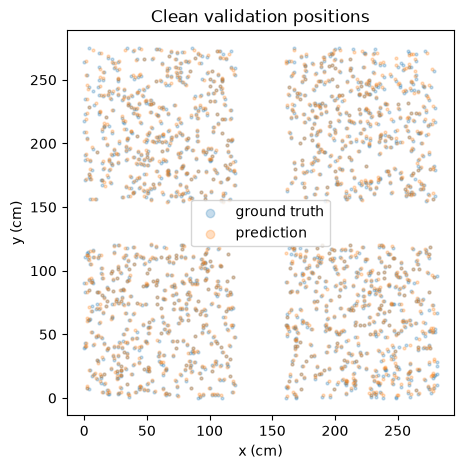

In [16]:
model.eval()
with torch.no_grad():
    float_norm = model(torch.from_numpy(X_val)).numpy()
float_pred_cm = target_min_cm + float_norm * target_range_cm
float_errors = euclidean_errors_cm(float_pred_cm, y_val_cm)

print(f"Float validation mean error:   {float_errors.mean():.3f} cm")
print(f"Float validation median error: {np.median(float_errors):.3f} cm")
print(f"Float validation p95 error:    {np.percentile(float_errors, 95):.3f} cm")

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_val_cm))
plt.scatter(y_val_cm[:n_show, 0], y_val_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(float_pred_cm[:n_show, 0], float_pred_cm[:n_show, 1], s=4, alpha=0.25, label="prediction")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Clean validation positions")
plt.show()

Raw test preprocessing comparison (frozen Task 1 model, no retraining):
no preprocessing           n=126460  mean=18.136cm  median= 5.563cm  p95=77.632cm
clipped to train range     n=126460  mean=18.102cm  median= 5.496cm  p95=77.634cm
Grouped 126460 raw rows into 52282 unique coordinates (2.42 repeats/coordinate on average)
grouped median             n= 52282  mean=11.169cm  median= 5.358cm  p95=40.150cm
grouped mean               n= 52282  mean=11.467cm  median= 6.569cm  p95=33.366cm
clipped + grouped mean     n= 52282  mean=11.483cm  median= 6.514cm  p95=33.666cm
thresholded denoise        n=126460  mean=18.865cm  median= 5.994cm  p95=79.393cm


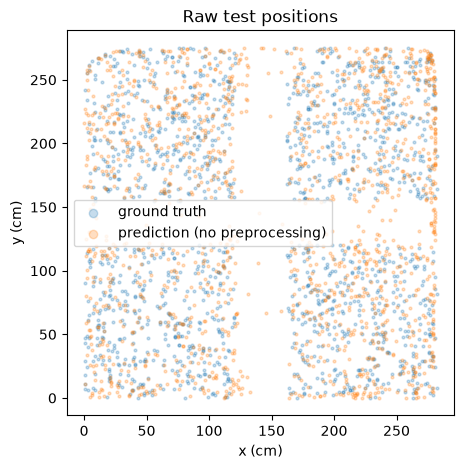

In [293]:
X_test = X_test_raw / rss_scale

def evaluate(X_norm, y_cm, label):
    model.eval()
    with torch.no_grad():
        pred_norm = model(torch.from_numpy(X_norm.astype(np.float32))).numpy()
    pred_cm = target_min_cm + pred_norm * target_range_cm
    errors = euclidean_errors_cm(pred_cm, y_cm)
    print(f"{label:<26} n={len(y_cm):6d}  mean={errors.mean():6.3f}cm  median={np.median(errors):6.3f}cm  p95={np.percentile(errors, 95):6.3f}cm")
    return pred_cm, errors

print("Raw test preprocessing comparison (frozen Task 1 model, no retraining):")
test_pred_cm, test_errors = evaluate(X_test, y_test_cm, "no preprocessing")

# --- 1) normalization / clipping ---
# Raw RSS is already roughly in [0, 1] but occasionally saturates at the sensor
# ceiling and runs systematically hotter than the clean-domain values the model
# was trained on. Clipping to the exact range seen during training keeps the
# frozen model from extrapolating outside what it actually learned.
X_clipped = np.clip(X_test_raw, 0.0, rss_scale) / rss_scale
clipped_pred_cm, clipped_errors = evaluate(X_clipped, y_test_cm, "clipped to train range")

# --- 2) median / averaging when grouped ---
# Raw data keeps repeated measurements per (x, y) coordinate; clean data is
# already the reconstructed fingerprint at each coordinate. Grouping the raw
# repeats by coordinate and taking their median (or mean) recovers the same
# kind of denoising the clean split benefits from, with no training involved.
coord_keys = [tuple(row) for row in np.round(y_test_cm).astype(int)]
groups: dict[tuple[int, int], list[int]] = {}
for i, key in enumerate(coord_keys):
    groups.setdefault(key, []).append(i)

grouped_median = np.empty((len(groups), X_test_raw.shape[1]), dtype=np.float32)
grouped_mean = np.empty_like(grouped_median)
grouped_y_cm = np.empty((len(groups), 2), dtype=np.float32)
for g, idx in enumerate(groups.values()):
    grouped_median[g] = np.median(X_test_raw[idx], axis=0)
    grouped_mean[g] = X_test_raw[idx].mean(axis=0)
    grouped_y_cm[g] = y_test_cm[idx].mean(axis=0)  # repeats share one coordinate

print(f"Grouped {len(X_test_raw)} raw rows into {len(groups)} unique coordinates "
      f"({len(X_test_raw) / len(groups):.2f} repeats/coordinate on average)")
grouped_median_pred_cm, grouped_median_errors = evaluate(grouped_median / rss_scale, grouped_y_cm, "grouped median")
grouped_mean_pred_cm, grouped_mean_errors = evaluate(grouped_mean / rss_scale, grouped_y_cm, "grouped mean")

# --- combo: clip raw readings, then group-average ---
# Grouped mean won on its own; clipping each raw repeat before averaging keeps
# a single saturated/outlier reading from dragging that coordinate's mean off,
# on top of the noise reduction the grouping already buys.
X_test_raw_clipped = np.clip(X_test_raw, 0.0, rss_scale)
grouped_mean_clipped = np.empty_like(grouped_mean)
for g, idx in enumerate(groups.values()):
    grouped_mean_clipped[g] = X_test_raw_clipped[idx].mean(axis=0)

combo_pred_cm, combo_errors = evaluate(grouped_mean_clipped / rss_scale, grouped_y_cm, "clipped + grouped mean")

# --- 3) simple deterministic denoising ---
# The clean split is ~42% exact zeros (an LED contributing nothing at that
# position). Raw sensor noise smears some of those true zeros into small
# positive readings. Snapping anything below a fixed threshold back to zero is
# a deterministic rule -- no fitting, no randomness -- that pushes the raw
# distribution back toward the sparsity pattern the model was trained on.
DENOISE_THRESHOLD = 0.02  # tune against the ~42% zero fraction in the clean split
X_denoised = np.where(X_test_raw < DENOISE_THRESHOLD, 0.0, X_test_raw) / rss_scale
denoised_pred_cm, denoised_errors = evaluate(X_denoised, y_test_cm, "thresholded denoise")

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_test_cm))
plt.scatter(y_test_cm[:n_show, 0], y_test_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(test_pred_cm[:n_show, 0], test_pred_cm[:n_show, 1], s=4, alpha=0.25, label="prediction (no preprocessing)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Raw test positions")
plt.show()

## Width/depth search for a small, accurate MLP

Reuses the tensors and scaling constants already computed above (`X_train_t`, `y_train_t`, `X_val_t`, `target_min_cm`, `target_range_cm`, `euclidean_errors_cm`) instead of recomputing them per trial. Each trial trains a candidate `hidden_sizes` architecture from scratch and reports `p95_cm` alongside parameter count, since on the RP2040 (no FPU) every extra parameter costs int8 fixed-point ops at inference time — the goal is the best accuracy-per-parameter tradeoff, not the lowest error in isolation.

`SEARCH_EPOCHS` is kept separate from the notebook's main `epochs` so the sweep stays fast; once you've picked a winner, retrain it at full `epochs` in the cells above.

In [242]:
def train_and_eval(hidden_sizes: list[int], seed: int = SEED) -> dict:
    torch.manual_seed(seed)
    candidate = build_mlp(X_train.shape[1], hidden_sizes)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    rng = np.random.default_rng(seed)

    for _ in range(SEARCH_EPOCHS):
        candidate.train()
        permutation = rng.permutation(len(X_train))
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(candidate(X_train_t[idx]), y_train_t[idx])
            loss.backward()
            optimizer.step()

    candidate.eval()
    with torch.no_grad():
        pred_norm = candidate(X_val_t).numpy()
    pred_cm = target_min_cm + pred_norm * target_range_cm
    errors = euclidean_errors_cm(pred_cm, y_val_cm)
    n_params = sum(p.numel() for p in candidate.parameters())
    return {
        "hidden_sizes": hidden_sizes,
        "n_params": n_params,
        "mean_cm": float(errors.mean()),
        "median_cm": float(np.median(errors)),
        "p95_cm": float(np.percentile(errors, 95)),
    }


SEARCH_EPOCHS = 80  # fewer than the main `epochs` -- this is a ranking pass, not a final fit

search_space = [
    [512] * 4,
    [32]*4,
    [256,512,512,256],
    [64,1024,256],
    [32,512,32],
    HIDDEN_SIZES,  # whatever you've currently set above, for comparison
]

search_results = [train_and_eval(hidden_sizes) for hidden_sizes in search_space]
search_results.sort(key=lambda r: r["p95_cm"])

print(f"{'hidden_sizes':<22}{'params':>8}{'mean_cm':>10}{'median_cm':>12}{'p95_cm':>10}")
for r in search_results:
    print(f"{str(r['hidden_sizes']):<22}{r['n_params']:>8}{r['mean_cm']:>10.3f}{r['median_cm']:>12.3f}{r['p95_cm']:>10.3f}")

hidden_sizes            params   mean_cm   median_cm    p95_cm
[512, 512, 512, 512]    794114     0.978       0.867     2.067
[256, 1024, 256]        528642     0.977       0.846     2.177
[64, 1024, 256]         330114     1.188       1.065     2.571
[256, 512, 512, 256]    528642     1.263       1.147     2.585
[32, 512, 32]            33698     1.680       1.350     4.123
[32, 32, 32, 32]          3554     2.189       1.869     4.995


In [17]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), models_dir / "ourmlp_task1.pt")
np.savez(
    models_dir / "ourmlp_task1_scaling.npz",
    rss_scale=np.asarray(rss_scale, dtype=np.float32),
    target_min_cm=target_min_cm.astype(np.float32),
    target_range_cm=target_range_cm.astype(np.float32),
    train_loss=history,
    float_errors=float_errors.astype(np.float32),
    hidden_sizes=np.asarray(HIDDEN_SIZES, dtype=np.int64),
)
print("Saved trained state and scaling constants")

Saved trained state and scaling constants


In [18]:
import subprocess
import sys

export_command = [
    sys.executable,
    str(ROOT / "scripts" / "export_litert_baseline.py"),
]

print("Running LiteRT export helper:")
print(" ".join(export_command))

subprocess.run(
    export_command,
    cwd=ROOT,
    check=True,
)

tflite_path = ROOT / "models" / "ourmlp_task1.tflite"
assert tflite_path.exists(), f"Export completed but {tflite_path} was not created."

print("TFLite bytes:", tflite_path.stat().st_size)

Running LiteRT export helper:
/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/bin/python3 /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/scripts/export_litert_baseline.py


W0709 13:36:24.017000 4688 .venv/lib/python3.12/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


(00:00) [START] LiteRT-Torch Convert
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default (+00:00)
(00:00) [START] LiteRT-Torch Convert > Run FX Passes


/Users/lschattenhofer/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:00) [START] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Run FX Passes (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module


/Users/lschattenhofer/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default (+00:00)
(00:01) [START] LiteRT-Torch Convert > Merge MLIR Modules
(00:01) [ DONE] LiteRT-Torch Convert > Merge MLIR Modules (+00:00)
(00:01) [START] LiteRT-Torch Convert > Run LiteRT Converter Passes
(00:01) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert (+00:01)
(00:00) [START] Write Model to Bytes
(00:00) [ DONE] Write Model to Bytes (+00:00)
Wrote /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/models/ourmlp_task1.tflite (351236 bytes)
Wrote /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/firmware/vlp_serial/vlp_model.tflite
Updated model_data.cc/.h and preprocessing/target scaling headers


/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:52: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  args_spec, kwargs_spec = spec.children_specs
/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:58: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  kwargs_spec.children_specs, kwargs_spec.context
I0000 00:00:1783596985.558664   46660 flatbuffer_export.cc:4346] Estimated count of arithmetic ops: 0.173 M  ops, equivalently 0.087 M  MACs


TFLite bytes: 351236


## Check the exported TFLite model

The same normalized validation vectors are sent through the exported flatbuffer using the LiteRT interpreter. The result should closely match the PyTorch model.

In [19]:
from ai_edge_litert.interpreter import Interpreter
tflite_bytes = tflite_path.read_bytes()
interpreter = Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]

print("Input dtype:", input_info["dtype"], "shape:", input_info["shape"])
print("Output dtype:", output_info["dtype"], "shape:", output_info["shape"])

pred_norm = np.empty((len(X_val), 2), dtype=np.float32)
for i, row in enumerate(X_val):
    interpreter.set_tensor(input_info["index"], row[None, :].astype(input_info["dtype"]))
    interpreter.invoke()
    pred_norm[i] = interpreter.get_tensor(output_info["index"])[0]

tflite_pred_cm = target_min_cm + pred_norm * target_range_cm
tflite_errors = euclidean_errors_cm(tflite_pred_cm, y_val_cm)
print(f"TFLite validation mean error:   {tflite_errors.mean():.3f} cm")
print(f"TFLite validation median error: {np.median(tflite_errors):.3f} cm")
print(f"TFLite validation p95 error:    {np.percentile(tflite_errors, 95):.3f} cm")

Input dtype: <class 'numpy.float32'> shape: [1 9]
Output dtype: <class 'numpy.float32'> shape: [1 2]
TFLite validation mean error:   0.983 cm
TFLite validation median error: 0.844 cm
TFLite validation p95 error:    2.228 cm


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Quantize to int8

Applies PT2E post-training static quantization directly to the `model` already trained above -- no separate training run needed. Calibration observers are fitted by running a sample of the already-computed `X_train` tensor through the exported graph; the resulting flatbuffer takes int8 in and int8 out. This is the actual win on the RP2040's Cortex-M0+, which has no hardware float unit -- int8 fixed-point ops run natively, float32 ops are emulated in software and much slower. Same technique as `notebooks/baseline_vlp_int8.ipynb`, just applied here so it quantizes the exact model you already validated instead of a separately retrained one.

In [20]:
import litert_torch
from litert_torch.quantize import pt2e_quantizer
from litert_torch.quantize.quant_config import QuantConfig
from torchao.quantization.pt2e import move_exported_model_to_eval, quantize_pt2e

CALIBRATION_SIZE = 2000  # subsample of X_train; raise for tighter quantization at the cost of a slower pass

model.eval()
example = (X_train_t[:1],)

exported = torch.export.export(model, example, strict=True).module()
quantizer = pt2e_quantizer.PT2EQuantizer().set_global(
    pt2e_quantizer.get_symmetric_quantization_config(is_per_channel=False)
)
prepared = quantize_pt2e.prepare_pt2e(exported, quantizer)

calib_idx = np.random.default_rng(SEED).choice(len(X_train), size=min(CALIBRATION_SIZE, len(X_train)), replace=False)
with torch.no_grad():
    for row in X_train[calib_idx]:
        prepared(torch.from_numpy(row[None, :]))

quantized = quantize_pt2e.convert_pt2e(prepared, fold_quantize=False)
quantized = move_exported_model_to_eval(quantized)

edge_model_int8 = litert_torch.convert(
    quantized,
    sample_args=example,
    strict_export=True,
    quant_config=QuantConfig(pt2e_quantizer=quantizer),
)
int8_tflite_bytes = edge_model_int8.model_content()

int8_tflite_path = models_dir / "ourmlp_task1_int8.tflite"
int8_tflite_path.write_bytes(int8_tflite_bytes)
print(f"Wrote {int8_tflite_path} ({len(int8_tflite_bytes)} bytes; float was {tflite_path.stat().st_size} bytes)")

W0709 13:36:47.226000 1472 .venv/lib/python3.12/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/Users/lschattenhofer/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:00) [ DONE] LiteRT-Torch Convert (+00:00)

(00:00) [START] Write Model to Bytes

I0000 00:00:1783597009.303665   23759 flatbuffer_export.cc:4346] Estimated count of arithmetic ops: 0.173 M  ops, equivalently 0.087 M  MACs


(00:00) [ DONE] Write Model to Bytes (+00:00)

Wrote /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/models/ourmlp_task1_int8.tflite (92704 bytes; float was 351236 bytes)


In [240]:
def quantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    if scale == 0:
        raise ValueError("Quantized tensor is missing scale information")
    dtype = tensor_info["dtype"]
    q = np.round(values / scale + zero_point)
    q = np.clip(q, np.iinfo(dtype).min, np.iinfo(dtype).max)
    return q.astype(dtype)

def dequantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    return (values.astype(np.float32) - zero_point) * scale

interpreter_int8 = Interpreter(model_content=int8_tflite_bytes)
interpreter_int8.allocate_tensors()
input_info = interpreter_int8.get_input_details()[0]
output_info = interpreter_int8.get_output_details()[0]
print("Input dtype:", input_info["dtype"], "quant:", input_info["quantization"])
print("Output dtype:", output_info["dtype"], "quant:", output_info["quantization"])
assert input_info["dtype"] == np.int8
assert output_info["dtype"] == np.int8

pred_norm = np.empty((len(X_val), 2), dtype=np.float32)
for i, row in enumerate(X_val):
    interpreter_int8.set_tensor(input_info["index"], quantize_tensor(row[None, :], input_info))
    interpreter_int8.invoke()
    pred_norm[i] = dequantize_tensor(interpreter_int8.get_tensor(output_info["index"]), output_info)[0]

int8_pred_cm = target_min_cm + pred_norm * target_range_cm
int8_errors = euclidean_errors_cm(int8_pred_cm, y_val_cm)
print(f"Int8 validation mean error:   {int8_errors.mean():.3f} cm")
print(f"Int8 validation median error: {np.median(int8_errors):.3f} cm")
print(f"Int8 validation p95 error:    {np.percentile(int8_errors, 95):.3f} cm")

Input dtype: <class 'numpy.int8'> quant: (0.0037542989011853933, -128)
Output dtype: <class 'numpy.int8'> quant: (0.00390625, -128)
Int8 validation mean error:   2.344 cm
Int8 validation median error: 2.213 cm
Int8 validation p95 error:    4.362 cm


## Test candidate firmware preprocessing: clip-to-train-range

Before touching `firmware/vlp_serial/main.cpp`, sanity-check the transform we plan to port there:
`clip(raw_rss, 0, rss_scale) / rss_scale` instead of the current plain `raw_rss / rss_scale`.

This runs it through the *actual exported models* (`tflite_bytes` float, `int8_tflite_bytes` quantized) on the raw test
set, so the numbers below are what the Pico would produce -- not just the frozen PyTorch model. Grouped mean/median are
excluded here: they require knowing which raw rows share a ground-truth coordinate, information the firmware never has
at inference time (one raw reading per request, no label).


In [22]:
def clip_to_train_range(X_raw):
    return np.clip(X_raw, 0.0, rss_scale) / rss_scale

X_test_noclip = X_test_raw / rss_scale
X_test_clipped = clip_to_train_range(X_test_raw)

def quantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    if scale == 0:
        raise ValueError("Quantized tensor is missing scale information")
    dtype = tensor_info["dtype"]
    q = np.round(values / scale + zero_point)
    q = np.clip(q, np.iinfo(dtype).min, np.iinfo(dtype).max)
    return q.astype(dtype)

def dequantize_tensor(values, tensor_info):
    scale, zero_point = tensor_info["quantization"]
    return (values.astype(np.float32) - zero_point) * scale

def run_tflite(model_bytes, X_norm, quantized):
    interp = Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    in_info = interp.get_input_details()[0]
    out_info = interp.get_output_details()[0]
    pred_norm = np.empty((len(X_norm), 2), dtype=np.float32)
    for i, row in enumerate(X_norm):
        if quantized:
            interp.set_tensor(in_info["index"], quantize_tensor(row[None, :], in_info))
        else:
            interp.set_tensor(in_info["index"], row[None, :].astype(np.float32))
        interp.invoke()
        raw_out = interp.get_tensor(out_info["index"])[0]
        pred_norm[i] = dequantize_tensor(raw_out, out_info) if quantized else raw_out
    return target_min_cm + pred_norm * target_range_cm

def report(pred_cm, label):
    errors = euclidean_errors_cm(pred_cm, y_test_cm)
    print(f"{label:<32} mean={errors.mean():6.3f}cm  median={np.median(errors):6.3f}cm  p95={np.percentile(errors, 95):6.3f}cm")
    return errors

print(f"Raw test set: n={len(X_test_raw)}")
report(run_tflite(tflite_bytes, X_test_noclip, quantized=False), "float, no clip (current firmware)")
report(run_tflite(tflite_bytes, X_test_clipped, quantized=False), "float, clipped")
report(run_tflite(int8_tflite_bytes, X_test_noclip, quantized=True), "int8, no clip (current firmware)")
report(run_tflite(int8_tflite_bytes, X_test_clipped, quantized=True), "int8, clipped")


ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-221' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-222' coro=<Kernel.shell_main() running at /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/lschattenhofer/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-222' coro=<Kernel.sh

Raw test set: n=126460
float, no clip (current firmware) mean=17.564cm  median= 6.064cm  p95=72.447cm
float, clipped                   mean=17.522cm  median= 5.974cm  p95=72.447cm
int8, no clip (current firmware) mean=18.179cm  median= 6.697cm  p95=72.762cm
int8, clipped                    mean=18.179cm  median= 6.697cm  p95=72.762cm


array([ 9.441887 , 73.41404  , 39.281433 , ...,  2.9579806, 19.727036 ,
        7.3200507], shape=(126460,), dtype=float32)

## Export directly into the Pico firmware template

Copies whichever model you pick via `USE_QUANTIZED_MODEL` below into `vlp_model.tflite`, regenerates `model_data.cc`/`.h` from it, and writes the preprocessing/de-normalization headers. The firmware template accepts either float32 or int8 model I/O, so both choices work as-is -- pick int8 for the real deployment target, float for debugging on host.

In [23]:
# Choose which model gets pushed to the Pico firmware template.
USE_QUANTIZED_MODEL = True  # set True to deploy the int8 model instead of the float one

firmware_dir = ROOT / "firmware" / "vlp_serial"
selected_tflite_bytes = int8_tflite_bytes if USE_QUANTIZED_MODEL else tflite_path.read_bytes()
(firmware_dir / "vlp_model.tflite").write_bytes(selected_tflite_bytes)

tflite_to_c_array(
    firmware_dir / "vlp_model.tflite",
    firmware_dir / "model_data.cc",
    firmware_dir / "model_data.h",
)

def c_float(value):
    text = f"{float(value):.9g}"
    if "." not in text and "e" not in text.lower():
        text += ".0"
    return text + "f"

(firmware_dir / "preprocess_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kRssScale = {c_float(rss_scale)};\n",
    encoding="utf-8",
)
(firmware_dir / "target_scale_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kTargetXMinCm = {c_float(target_min_cm[0])};\n"
    f"constexpr float kTargetYMinCm = {c_float(target_min_cm[1])};\n"
    f"constexpr float kTargetXRangeCm = {c_float(target_range_cm[0])};\n"
    f"constexpr float kTargetYRangeCm = {c_float(target_range_cm[1])};\n",
    encoding="utf-8",
)
print(f"Firmware model ({'int8' if USE_QUANTIZED_MODEL else 'float'}) and headers updated in:", firmware_dir)

ERROR:autoreload:Failed to reload module 'jedi.inference.cache' from file '/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/jedi/inference/cache.py'
Traceback (most recent call last):
  File "/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
  File "/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 451, in update_generic
    update(a, b)
  File "/Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 419, in update_class
    update_instances(old, new)


Firmware model (int8) and headers updated in: /Users/lschattenhofer/Documents/Code/SYS_AI_VLP_Hackathon/firmware/vlp_serial
